In [7]:
from langgraph.graph import StateGraph, START, END
from typing import TypedDict, Annotated, Literal
import operator

In [8]:
class State(TypedDict):
    value: int
    max_value: int
    current_step: Annotated[list[int], operator.add]


In [9]:
def current_step(state: State) -> dict:
    current = state['value'] 
    return {'current_step': [current] }

In [10]:
def increment(state: State) -> State:
    current = state['value']
    incremented = current + 1

    return {'value': incremented}

In [11]:
def conditional_check(state: State) -> Literal['increment', 'END']:
    if state['value'] < state['max_value']:
        return 'increment'
    else:
        return 'END'


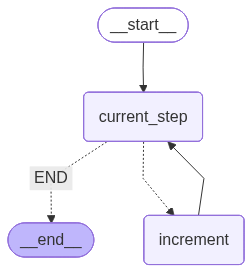

In [12]:
graph = StateGraph(State)

graph.add_node('current_step', current_step)
graph.add_node('increment', increment)

graph.add_edge(START, 'current_step')
graph.add_conditional_edges('current_step', conditional_check, {'increment': 'increment', 'END': END})
graph.add_edge('increment', 'current_step')

graph.compile()

In [13]:
workflow = graph.compile()

In [14]:
initial_state = {'value': 0, 'max_value': 5}

result = workflow.invoke(initial_state)

In [15]:
result

{'value': 5, 'max_value': 5, 'current_step': [0, 1, 2, 3, 4, 5]}